In [1]:
# ============================================================
# FULL STEADY-STATE REACTOR + PARAMETRIC + MULTI-KINETICS
# ============================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt
from fipy.tools import numerix


def safe(x):
    return numerix.maximum(x, 1e-8)

def safe_exp(x):
    return numerix.exp(numerix.clip(x, -100, 100))

def safe_div(numer, denom, eps=1e-12):
    return numer / numerix.maximum(denom, eps)
    
# -----------------------------
# Global constants
# -----------------------------
R = 8.314
rho_b = 1200
eps = 0.4
Dr, Dz = 1e-5, 1e-5
lambda_e = 0.8
dH = [-165e3, 41e3, -206e3]

species = ["H2", "CO2", "CH4", "H2O", "CO"]

nu = {
    "H2":  [-4, -1, -3],
    "CO2": [-1, -1,  0],
    "CH4": [ 1,  0,  1],
    "H2O": [ 2,  1,  1],
    "CO":  [ 0,  1, -1]
}


# ============================================================
# KINETIC MODELS
# ============================================================

def champom_kinetics(p, T, k):

    kco2  = k["k0co2"]  * safe_exp(-k["eaco2"]/(R*T))
    krwgs = k["k0rwgs"] * safe_exp(-k["earwgs"]/(R*T))
    kco   = k["k0co"]   * safe_exp(-k["eaco"]/(R*T))

    Keq = 137*T**(-3.998)*safe_exp(158700/(R*T))

    Kco  = k["kads0co"]  * safe_exp(k["deltahco"]  /(R*T))
    Kh2  = k["kads0h2"]  * safe_exp(k["deltahh2"]  /(R*T))
    Kh2o = k["kads0h2o"] * safe_exp(k["deltahh2o"] /(R*T))
    Kco2 = k["kads0co2"] * safe_exp(k["deltahco2"] /(R*T))

    denom = 1 + Kh2*p["H2"] + Kco2*p["CO2"] + Kh2o*p["H2O"] + Kco*p["CO"]

    driving = safe_div(1 - (p["CH4"]*p["H2O"]**2)/(p["CO2"]*p["H2"]**4*Keq), 1)
    driving = numerix.clip(driving, 0, 1)

    r1 = kco2 * Kh2 * Kco2 * p["H2"] * p["CO2"] * driving / numerix.maximum(denom**2, 1e-12)
    r2 = krwgs * p["CO2"] / numerix.maximum(denom, 1e-12)
    r3   = kco * p["CO"] * p["H2"] / numerix.maximum(denom**2, 1e-12)
    
    return [r1, r2, r3]

def koz_kinetics(p, T, k):
    kf = k["k0"] * safe_exp(-k["Ea"]/(R*T))
    Keq = 137*T**(-3.998)*safe_exp(158700/(R*T))

    K_OH  = numerix.exp(k["Aoh"]  + k["Boh"]/T)
    K_H2  = numerix.exp(k["Ah2"]  + k["Bh2"]/T)
    K_mix = numerix.exp(k["Amix"] + k["Bmix"]/T)

    driving = safe_div(1 - (p["CH4"]*p["H2O"]**2)/(p["CO2"]*p["H2"]**4*Keq),1)
    driving = numerix.clip(driving,0,1)

    num = kf * p["H2"]**0.5 * p["CO2"]**0.5 * driving
    den = (1 + K_OH*(p["H2O"]/p["H2"]**0.5) + K_H2*p["H2"]**0.5 + K_mix*p["CO2"]**0.5)**2

    return safe_div(num, den), 0.0, 0.0

# ============================================================
# REACTOR SOLVER
# ============================================================

def run_reactor(H2_CO2, Twall, u0, Pbar, kinetics, kin_params):

    Rr, Lz = 0.01, 0.2
    Nr, Nz = 20, 60
    mesh = CylindricalGrid2D(dr=Rr/Nr, dz=Lz/Nz, nr=Nr, nz=Nz)

    Tin = 600
    yCO2 = 1/(1+H2_CO2)
    yH2  = H2_CO2*yCO2

    Cin = {
        "CO2": Pbar*1e5*yCO2/(R*Tin),
        "H2":  Pbar*1e5*yH2 /(R*Tin),
        "CH4": 1e-6,
        "CO":  1e-6,
        "H2O": 1e-6
    }

    C = {sp: CellVariable(mesh=mesh, value=Cin[sp]) for sp in species}
    T = CellVariable(mesh=mesh, value=Tin)
    
    for sp in species:
        C[sp].constrain(Cin[sp], mesh.facesBottom)
        C[sp].faceGrad.constrain(0, mesh.facesTop)

    T.constrain(Tin, mesh.facesBottom)
    T.constrain(Twall, mesh.facesTop)

    p = {sp: safe(C[sp] * R * T / 1e5) for sp in species}
    rates = kinetics(p, T, kin_params)

    eqs = []
    for sp in species:
        Rsp = sum(nu[sp][i]*rates[i] for i in range(3))
        eqs.append(
            ConvectionTerm(coeff=(0, u0), var=C[sp])
            ==
            DiffusionTerm(coeff=((eps*Dr, eps*Dz)), var=C[sp])
            + rho_b*Rsp
        )

    energy = (
        DiffusionTerm(coeff=lambda_e, var=T)
        + rho_b*sum(-dH[i]*rates[i] for i in range(3))
    )
    
    for it in range(200):
        for eq in eqs:
            eq.solve(dt=1e-3)
        energy.solve(dt=1e-3)

    if it % 20 == 0:
        print(f"    iter {it:3d} | Tmax = {T.value.max():.1f} K")
        
    if it % 50 == 0:
        plt.clf()
        plt.plot(T.value)
        plt.title(f"Iteration {it}")
        plt.pause(0.01)


    cl = lambda v: v.value.reshape(Nr, Nz)[0, :]
    CO2_in, CO2_out = Cin["CO2"], cl(C["CO2"])[-1]
    CH4_out = cl(C["CH4"])[-1]

    X = (CO2_in-CO2_out)/CO2_in
    S = CH4_out/(CO2_in-CO2_out+1e-12)
    
    return X, S, T.value.reshape(Nr, Nz)

# ============================================================
# PARAMETERS
# ============================================================

# ---- Champom kinetics ----
kin_champom = dict(
    k0co2=1900000, eaco2=110000,
    k0rwgs=29666.66667, earwgs=97100,
    k0co=3716666.667, eaco=97300,
    kads0co=0.00239, deltahco=40600,
    kads0h2=0.000052, deltahh2=52000,
    kads0h2o=0.609, deltahh2o=14500,
    kads0co2=1.07, deltahco2=9720
)

kin_koz = dict(
    k0=3.46e-5,
    Ea=77500,
    Aoh=0.5, Boh=-2694.25,
    Ah2=0.44, Bh2=745.73,
    Amix=0.88, Bmix=1202.79
)

ratios = [2, 3, 4, 5]
Twalls = [550, 600, 650]
vels = [0.1, 0.2]
pressures = [5, 10]

# ============================================================
# PARAMETRIC SWEEP
# ============================================================

results = []

case = 0
total = len(ratios)*len(Twalls)*len(vels)*len(pressures)*2

for r in ratios:
    for Tw in Twalls:
        for u in vels:
            for P in pressures:
                case += 1
                print(f"▶ Case {case}/{total} | H2/CO2={r}, T={Tw}, u={u}, P={P}")

                Xc, Sc, Tc = run_reactor(r, Tw, u, P,
                                     champom_kinetics, kin_champom)
                Xk, Sk, Tk = run_reactor(r, Tw, u, P,
                                     koz_kinetics, kin_koz)
                results.append([r, Tw, u, P, Xc, Sc, Xk, Sk])

results1 = np.array(results)

results = pd.DataFrame(
    results,
    columns=["H2_CO2", "Twall", "u0", "P",
             "X_ch", "S_ch", "X_koz", "S_koz"]
)

# ============================================================
# PLOTS
# ============================================================


for u in results.u0.unique():
    sub = results[results.u0 == u]

    plt.figure()
    plt.plot(sub.Twall, sub.X_ch, 'o-', label="Conversion (Champom)")
    plt.plot(sub.Twall, sub.X_koz, 's--', label="Conversion (Koz)")
    plt.xlabel("Wall temperature [K]")
    plt.ylabel("CO₂ conversion")
    plt.title(f"Effect of Temperature (u₀ = {u} m/s)")
    plt.legend()
    plt.grid(True)
    plt.show()

for Tw in results.Twall.unique():
    sub = results[results.Twall == Tw]

    plt.figure()
    plt.plot(sub.P, sub.X_ch, 'o-', label="Champom")
    plt.plot(sub.P, sub.X_koz, 's--', label="Koz")
    plt.xlabel("Pressure [bar]")
    plt.ylabel("CO₂ conversion")
    plt.title(f"Effect of Pressure (Twall = {Tw} K)")
    plt.legend()
    plt.grid(True)
    plt.show()

for P in results.P.unique():
    sub = results[results.P == P]

    plt.figure()
    plt.plot(sub.u0, sub.X_ch, 'o-', label="Champom")
    plt.plot(sub.u0, sub.X_koz, 's--', label="Koz")
    plt.xlabel("Superficial velocity u₀ [m/s]")
    plt.ylabel("CO₂ conversion")
    plt.title(f"Effect of Velocity (P = {P} bar)")
    plt.legend()
    plt.grid(True)
    plt.show()

plt.figure()
plt.scatter(results.X_ch, results.S_ch, c=results.Twall,
            cmap="inferno", label="Champom")
plt.colorbar(label="Twall [K]")
plt.xlabel("Conversion")
plt.ylabel("CO selectivity")
plt.title("Selectivity vs Conversion (Champom)")
plt.grid(True)
plt.show()

Z, R = np.meshgrid(
    np.linspace(0, L, Nz),
    np.linspace(0, Rr, Nr)
)

plt.figure(figsize=(7,4))
plt.contourf(Z, R, Tfield, 30)
plt.colorbar(label="Temperature [K]")
plt.xlabel("Axial position z [m]")
plt.ylabel("Radial position r [m]")
plt.title("Temperature field inside reactor")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.contourf(Z, R, C_CO2, 30)
plt.colorbar(label="CO₂ concentration [mol/m³]")
plt.xlabel("z [m]")
plt.ylabel("r [m]")
plt.title("CO₂ consumption profile")
plt.show()

▶ Case 1/96 | H2/CO2=2, T=550, u=0.1, P=5


C:\Users\pingu\anaconda3\Lib\site-packages\fipy\variables\variable.py:1130: RuntimeWarning: invalid value encountered in divide
  return self._BinaryOperatorVariable(lambda a, b: a / b, other)
C:\Users\pingu\anaconda3\Lib\site-packages\fipy\terms\term.py:195: UserWarning: sweep() or solve() are likely to produce erroneous results when `var` does not contain floats.
  solver = self._prepareLinearSystem(var, solver, boundaryConditions, dt)


▶ Case 2/96 | H2/CO2=2, T=550, u=0.1, P=10
▶ Case 3/96 | H2/CO2=2, T=550, u=0.2, P=5
▶ Case 4/96 | H2/CO2=2, T=550, u=0.2, P=10
▶ Case 5/96 | H2/CO2=2, T=600, u=0.1, P=5
▶ Case 6/96 | H2/CO2=2, T=600, u=0.1, P=10
▶ Case 7/96 | H2/CO2=2, T=600, u=0.2, P=5
▶ Case 8/96 | H2/CO2=2, T=600, u=0.2, P=10
▶ Case 9/96 | H2/CO2=2, T=650, u=0.1, P=5
▶ Case 10/96 | H2/CO2=2, T=650, u=0.1, P=10
▶ Case 11/96 | H2/CO2=2, T=650, u=0.2, P=5
▶ Case 12/96 | H2/CO2=2, T=650, u=0.2, P=10
▶ Case 13/96 | H2/CO2=3, T=550, u=0.1, P=5
▶ Case 14/96 | H2/CO2=3, T=550, u=0.1, P=10
▶ Case 15/96 | H2/CO2=3, T=550, u=0.2, P=5
▶ Case 16/96 | H2/CO2=3, T=550, u=0.2, P=10
▶ Case 17/96 | H2/CO2=3, T=600, u=0.1, P=5
▶ Case 18/96 | H2/CO2=3, T=600, u=0.1, P=10
▶ Case 19/96 | H2/CO2=3, T=600, u=0.2, P=5
▶ Case 20/96 | H2/CO2=3, T=600, u=0.2, P=10
▶ Case 21/96 | H2/CO2=3, T=650, u=0.1, P=5
▶ Case 22/96 | H2/CO2=3, T=650, u=0.1, P=10
▶ Case 23/96 | H2/CO2=3, T=650, u=0.2, P=5
▶ Case 24/96 | H2/CO2=3, T=650, u=0.2, P=10
▶ Case 

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

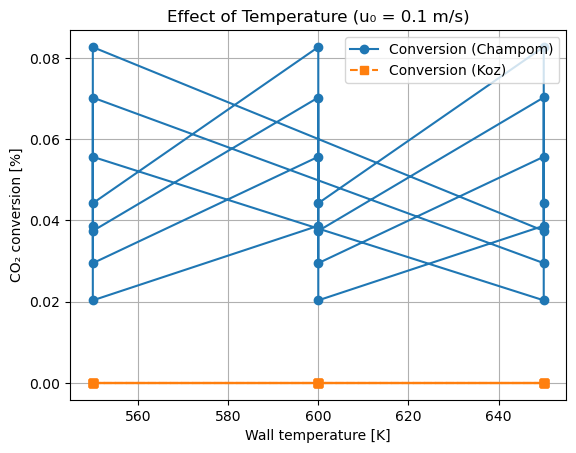

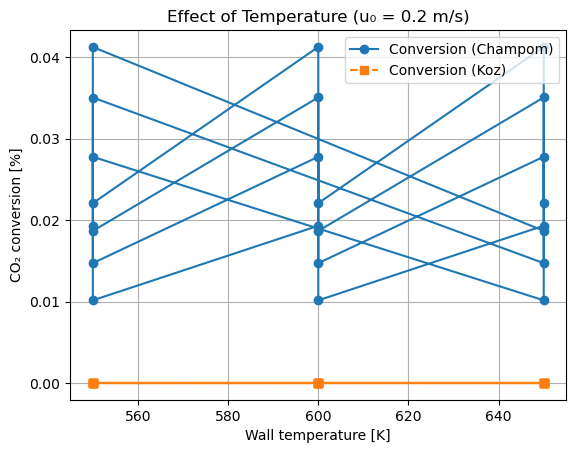

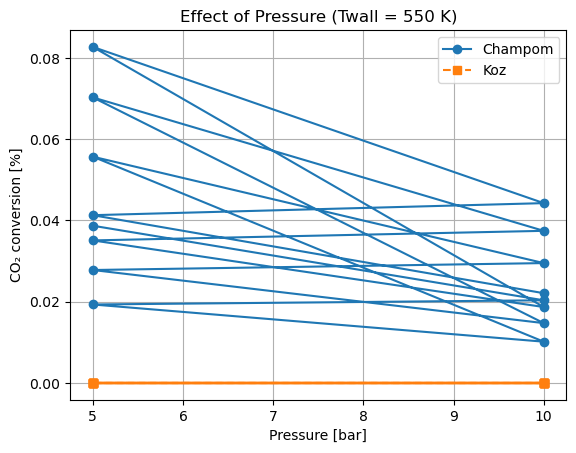

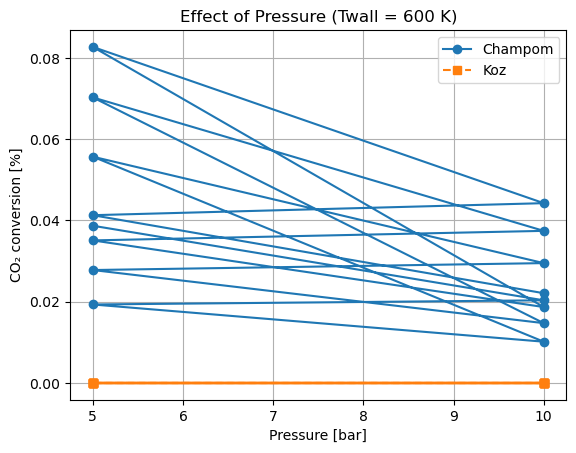

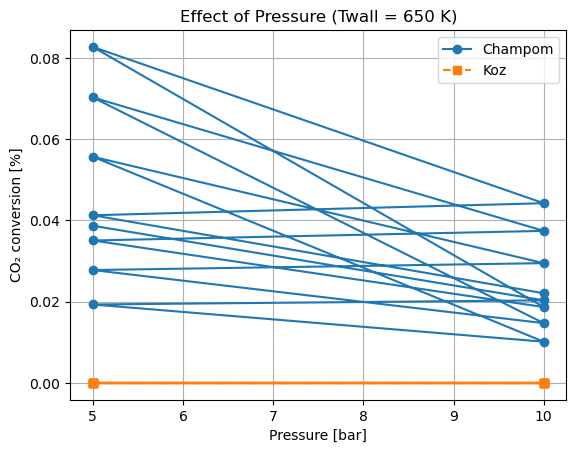

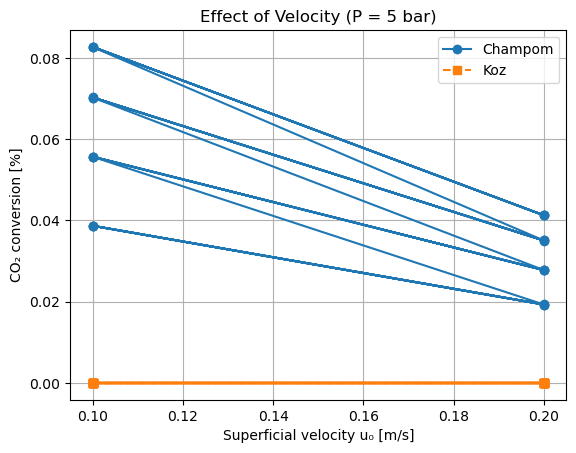

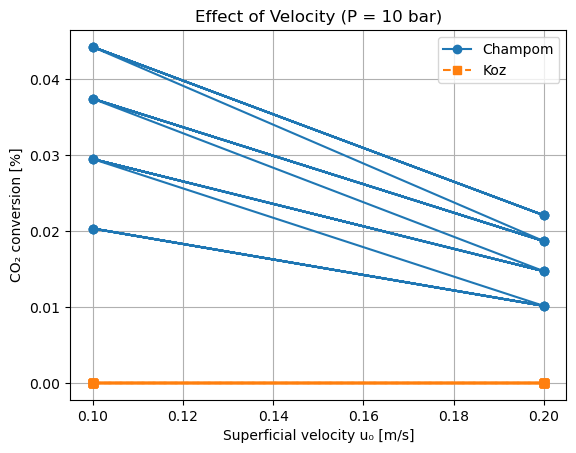

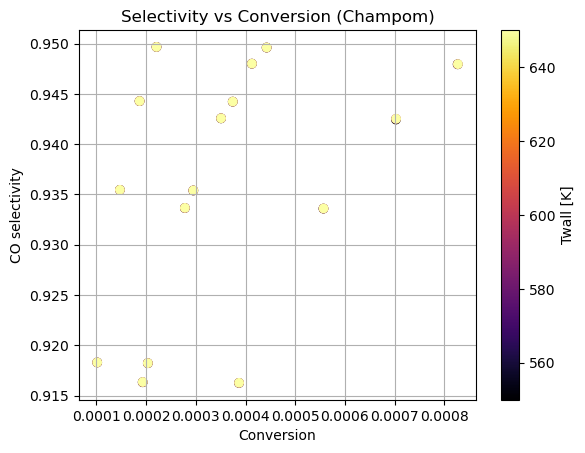

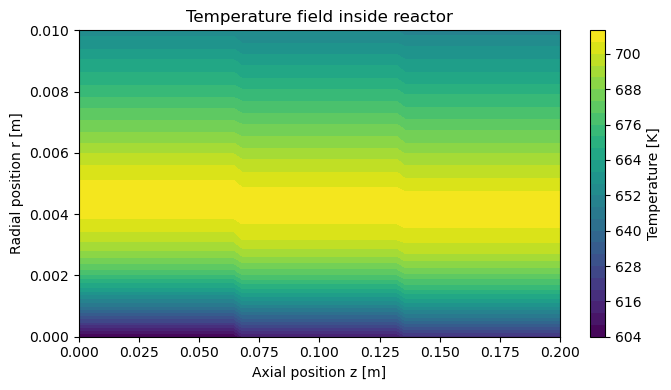

NameError: name 'C_CO2' is not defined

<Figure size 700x400 with 0 Axes>

In [10]:
results1 = np.array(results)

results = pd.DataFrame(
    results,
    columns=["H2_CO2", "Twall", "u0", "P",
             "X_ch", "S_ch", "X_koz", "S_koz"]
)


for u in results.u0.unique():
    sub = results[results.u0 == u]

    plt.figure()
    plt.plot(sub.Twall, sub.X_ch*100, 'o-', label="Conversion (Champom)")
    plt.plot(sub.Twall, sub.X_koz*100, 's--', label="Conversion (Koz)")
    plt.xlabel("Wall temperature [K]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Temperature (u₀ = {u} m/s)")
    plt.legend()
    plt.grid(True)
    plt.show()

for Tw in results.Twall.unique():
    sub = results[results.Twall == Tw]

    plt.figure()
    plt.plot(sub.P, sub.X_ch*100, 'o-', label="Champom")
    plt.plot(sub.P, sub.X_koz*100, 's--', label="Koz")
    plt.xlabel("Pressure [bar]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Pressure (Twall = {Tw} K)")
    plt.legend()
    plt.grid(True)
    plt.show()

for P in results.P.unique():
    sub = results[results.P == P]

    plt.figure()
    plt.plot(sub.u0, sub.X_ch*100, 'o-', label="Champom")
    plt.plot(sub.u0, sub.X_koz*100, 's--', label="Koz")
    plt.xlabel("Superficial velocity u₀ [m/s]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Velocity (P = {P} bar)")
    plt.legend()
    plt.grid(True)
    plt.show()

plt.figure()
plt.scatter(results.X_ch, results.S_ch, c=results.Twall,
            cmap="inferno", label="Champom")
plt.colorbar(label="Twall [K]")
plt.xlabel("Conversion")
plt.ylabel("CO selectivity")
plt.title("Selectivity vs Conversion (Champom)")
plt.grid(True)
plt.show()

Z, R = np.meshgrid(
    np.linspace(0, Lz, Nz),
    np.linspace(0, Rr, Nr)
)

plt.figure(figsize=(7,4))
plt.contourf(Z, R, Tc, 30)
plt.colorbar(label="Temperature [K]")
plt.xlabel("Axial position z [m]")
plt.ylabel("Radial position r [m]")
plt.title("Temperature field inside reactor")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
plt.contourf(Z, R, C_CO2, 30)
plt.colorbar(label="CO₂ concentration [mol/m³]")
plt.xlabel("z [m]")
plt.ylabel("r [m]")
plt.title("CO₂ consumption profile")
plt.show()

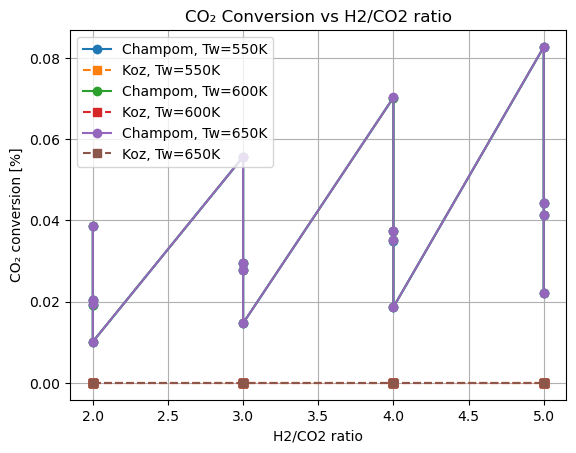

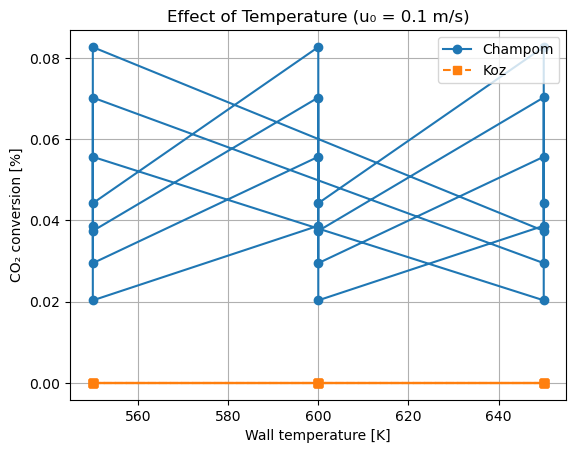

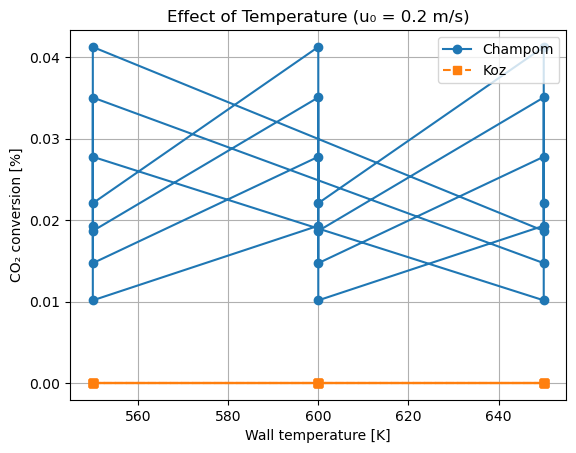

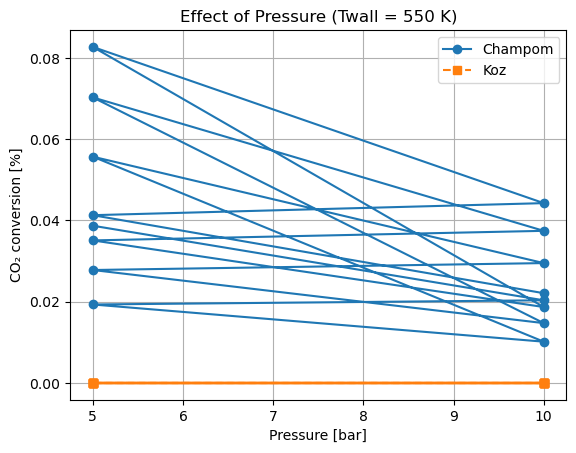

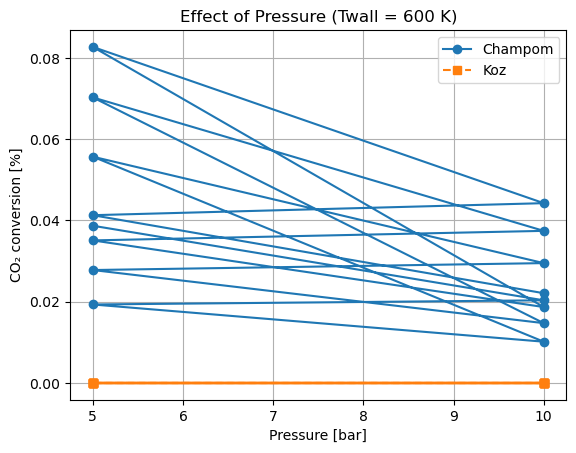

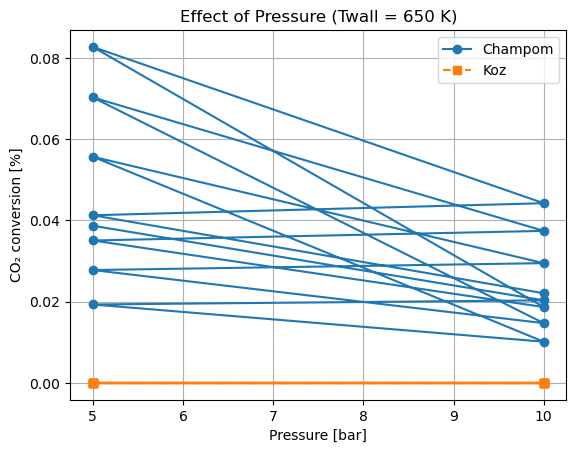

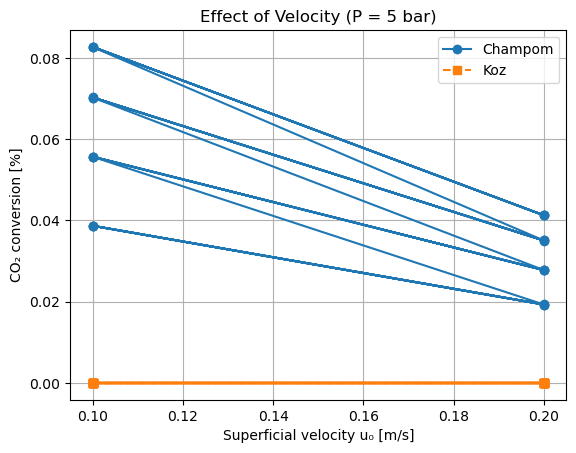

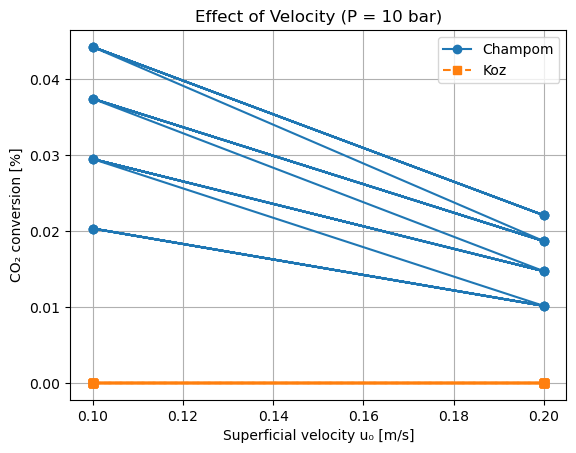

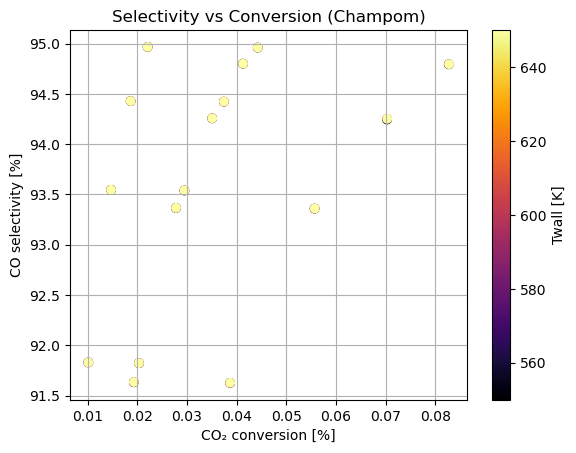

,H2_CO2,Twall,u0,P,X_ch,S_ch,X_koz,S_koz,X_ch_pct,X_koz_pct,S_ch_pct,S_koz_pct
0,2,550,0.1,5,0.000387,0.916258,0.0,1000000.0,0.038682,0.0,91.625774,100000000.0
1,2,550,0.1,10,0.000203,0.918220,0.0,1000000.0,0.020332,0.0,91.821981,100000000.0
2,2,550,0.2,5,0.000193,0.916325,0.0,1000000.0,0.019303,0.0,91.632528,100000000.0
3,2,550,0.2,10,0.000101,0.918295,0.0,1000000.0,0.010147,0.0,91.829523,100000000.0
4,2,600,0.1,5,0.000387,0.916264,0.0,1000000.0,0.038688,0.0,91.626394,100000000.0
5,2,600,0.1,10,0.000203,0.918225,0.0,1000000.0,0.020334,0.0,91.822507,100000000.0
6,2,600,0.2,5,0.000193,0.916338,0.0,1000000.0,0.019309,0.0,91.633802,100000000.0
7,2,600,0.2,10,0.000101,0.918294,0.0,1000000.0,0.010147,0.0,91.829420,100000000.0
8,2,650,0.1,5,0.000387,0.916272,0.0,1000000.0,0.038696,0.0,91.627231,100000000.0
9,2,650,0.1,10,0.000203,0.918228,0.0,1000000.0,0.020336,0.0,91.822778,100000000.0


In [13]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def radial_avg(Cvar, Nr, Nz):
    """Return radial average along reactor length (axis=0 is radial)."""
    return np.mean(Cvar.reshape(Nr, Nz), axis=0)

# ============================================================
# PLOTS
# ============================================================

# Convert conversion and selectivity to percent
results["X_ch_pct"] = results["X_ch"] * 100
results["X_koz_pct"] = results["X_koz"] * 100
results["S_ch_pct"] = results["S_ch"] * 100
results["S_koz_pct"] = results["S_koz"] * 100

# --- CO2 Conversion vs H2/CO2 ratio ---
plt.figure()
for Tw in Twalls:
    sub = results[results.Twall == Tw]
    plt.plot(sub.H2_CO2, sub.X_ch_pct, "o-", label=f"Champom, Tw={Tw}K")
    plt.plot(sub.H2_CO2, sub.X_koz_pct, "s--", label=f"Koz, Tw={Tw}K")

plt.xlabel("H2/CO2 ratio")
plt.ylabel("CO₂ conversion [%]")
plt.title("CO₂ Conversion vs H2/CO2 ratio")
plt.legend()
plt.grid(True)
plt.show()

# --- CO2 Conversion vs Wall Temperature ---
for u in results.u0.unique():
    sub = results[results.u0 == u]
    plt.figure()
    plt.plot(sub.Twall, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.Twall, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Wall temperature [K]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Temperature (u₀ = {u} m/s)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- CO2 Conversion vs Pressure ---
for Tw in results.Twall.unique():
    sub = results[results.Twall == Tw]
    plt.figure()
    plt.plot(sub.P, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.P, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Pressure [bar]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Pressure (Twall = {Tw} K)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- CO2 Conversion vs Velocity ---
for P in results.P.unique():
    sub = results[results.P == P]
    plt.figure()
    plt.plot(sub.u0, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.u0, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Superficial velocity u₀ [m/s]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Velocity (P = {P} bar)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Selectivity vs Conversion ---
plt.figure()
plt.scatter(results.X_ch_pct, results.S_ch_pct, c=results.Twall,
            cmap="inferno", label="Champom")
plt.colorbar(label="Twall [K]")
plt.xlabel("CO₂ conversion [%]")
plt.ylabel("CO selectivity [%]")
plt.title("Selectivity vs Conversion (Champom)")
plt.grid(True)
plt.show()

results

▶ Case 1 / 8 | H2/CO2=4, T=600, u=0.1, P=7
▶ Case 2 / 8 | H2/CO2=4, T=600, u=0.1, P=10
▶ Case 3 / 8 | H2/CO2=4, T=600, u=0.5, P=7
▶ Case 4 / 8 | H2/CO2=4, T=600, u=0.5, P=10
▶ Case 5 / 8 | H2/CO2=4, T=650, u=0.1, P=7
▶ Case 6 / 8 | H2/CO2=4, T=650, u=0.1, P=10
▶ Case 7 / 8 | H2/CO2=4, T=650, u=0.5, P=7
▶ Case 8 / 8 | H2/CO2=4, T=650, u=0.5, P=10


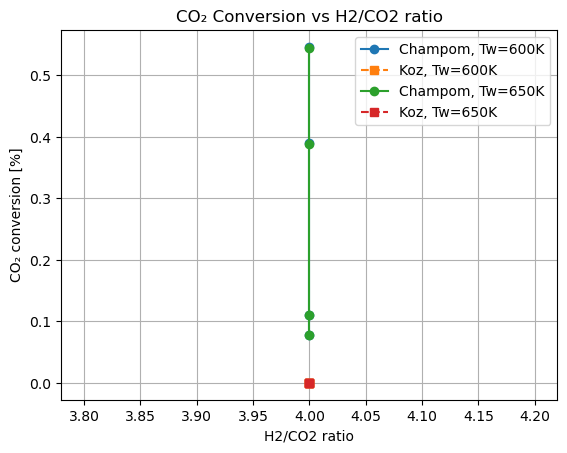

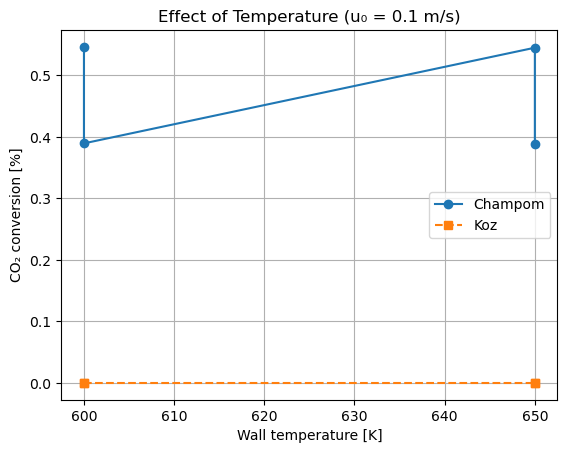

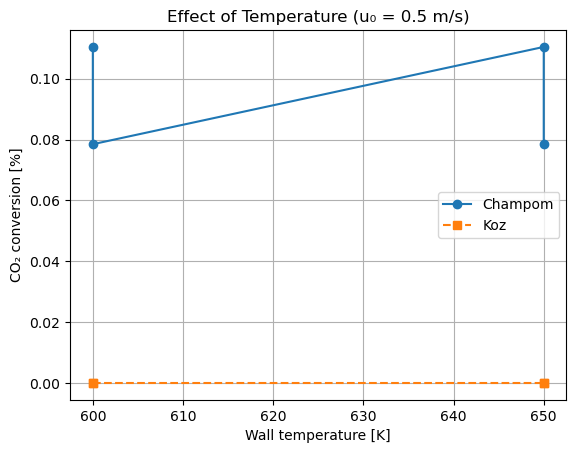

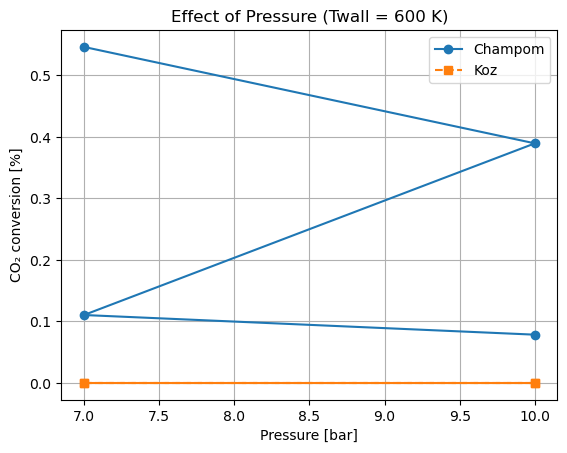

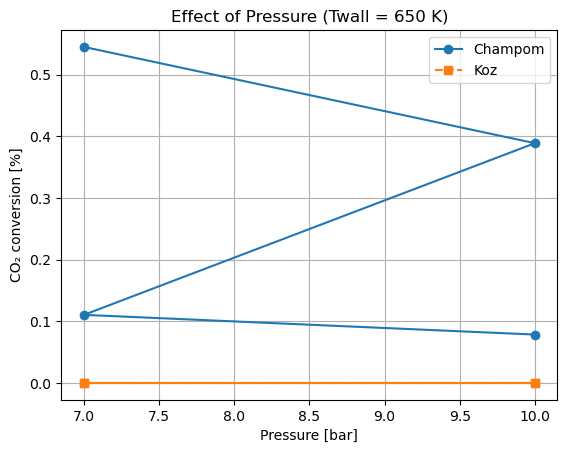

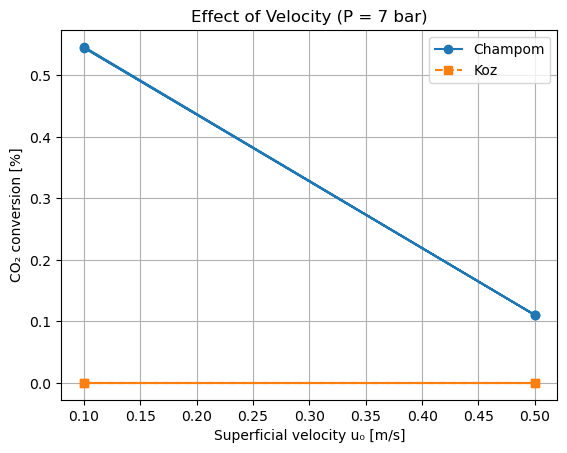

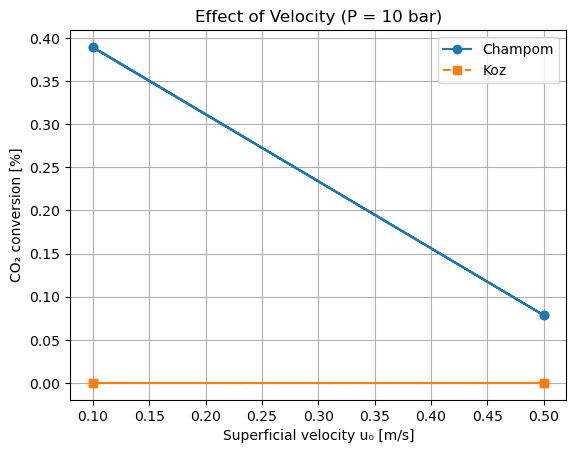

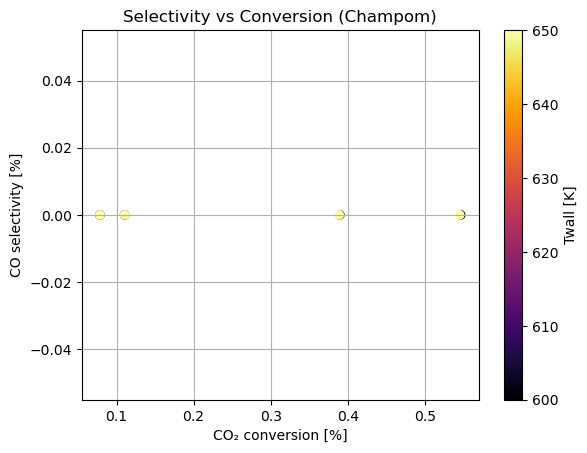

In [2]:
# ============================================================
# FULL STEADY-STATE REACTOR + PARAMETRIC + MULTI-KINETICS
# ============================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt
from fipy.tools import numerix
import pandas as pd

def safe(x):
    return numerix.maximum(x, 1e-8)

def safe_exp(x):
    return numerix.exp(numerix.clip(x, -100, 100))

def safe_div(numer, denom, eps=1e-12):
    return numer / numerix.maximum(denom, eps)

def radial_avg(Cvar, Nr, Nz):
    """Return radial average along reactor length (axis=0 is radial)."""
    return np.mean(Cvar.reshape(Nr, Nz), axis=0)

# -----------------------------
# Global constants
# -----------------------------
R = 8.314
rho_b = 2450
eps = 0.4
Dr, Dz = 1e-5, 1e-5
lambda_e = 0.8
dH = [-165e3, 41e3, -206e3]
Rr, Lz = 0.01, 1
Nr, Nz = 20, 60
Tin = 600

species = ["H2", "CO2", "CH4", "H2O", "CO"]

nu = {
    "H2":  [-4, -1, -3],
    "CO2": [-1, -1,  0],
    "CH4": [ 1,  0,  1],
    "H2O": [ 2,  1,  1],
    "CO":  [ 0,  1, -1]
}


# ============================================================
# KINETIC MODELS
# ============================================================

def champom_kinetics(p, T, k):

    kco2  = k["k0co2"]  * safe_exp(-k["eaco2"] / (R*T))
    krwgs = k["k0rwgs"] * safe_exp(-k["earwgs"] / (R*T))
    kco   = k["k0co"]   * safe_exp(-k["eaco"] / (R*T))

    Keq = 137* T**(-3.998) * safe_exp(158700/(R*T))

    Kco  = k["kads0co"]  * safe_exp(k["deltahco"]  / (R*T))
    Kh2  = k["kads0h2"]  * safe_exp(k["deltahh2"]  / (R*T))
    Kh2o = k["kads0h2o"] * safe_exp(k["deltahh2o"] / (R*T))
    Kco2 = k["kads0co2"] * safe_exp(k["deltahco2"] / (R*T))

    denom = 1 + Kh2 * p["H2"] + Kco2 * p["CO2"] + Kh2o * p["H2O"] + Kco * p["CO"]

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2) / (p["CO2"] * p["H2"]**4 * Keq), 1)
    driving = numerix.clip(driving, 0, 1)

    r1 = kco2 * Kh2 * Kco2 * p["H2"] * p["CO2"] * driving / numerix.maximum(denom**2, 1e-12)
    r2 = krwgs * p["CO2"] / numerix.maximum(denom, 1e-12)
    r3   = kco * p["CO"] * p["H2"] / numerix.maximum(denom**2, 1e-12)
    
    return [r1, r2, r3]

def koz_kinetics(p, T, k):
    kf = k["k0"] * safe_exp(-k["Ea"] / (R*T))
    Keq = 137 * T**(-3.998) * safe_exp(158700 / (R*T))

    K_OH  = numerix.exp(k["Aoh"]  + k["Boh"] / T)
    K_H2  = numerix.exp(k["Ah2"]  + k["Bh2"] / T)
    K_mix = numerix.exp(k["Amix"] + k["Bmix"] / T)

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2)/(p["CO2"] * p["H2"]**4 * Keq),1)
    driving = numerix.clip(driving,0,1)

    num = kf * p["H2"]**0.5 * p["CO2"]**0.5 * driving
    den = (1 + K_OH*(p["H2O"] / p["H2"]**0.5) + K_H2*p["H2"]**0.5 + K_mix*p["CO2"]**0.5)**2

    return safe_div(num, den), 0.0, 0.0

# ============================================================
# REACTOR SOLVER
# ============================================================

def run_reactor(H2_CO2, Twall, u0, Pbar, kinetics, kin_params):

    Rr, Lz = 0.01, 1
    Nr, Nz = 20, 60
    mesh = CylindricalGrid2D(dr=Rr/Nr, dz=Lz/Nz, nr=Nr, nz=Nz)

    Tin = 600
    yCO2 = 1/(1+H2_CO2)
    yH2  = H2_CO2*yCO2

    Cin = {
        "CO2": Pbar * 1e5 * yCO2 / (R*Tin),
        "H2":  Pbar * 1e5 * yH2 / (R*Tin),
        "CH4": 0,
        "CO":  0,
        "H2O": 1e-6
    }

    C = {sp: CellVariable(mesh=mesh, value=Cin[sp]) for sp in species}
    T = CellVariable(mesh=mesh, value=Tin)
    
    for sp in species:
        C[sp].constrain(Cin[sp], mesh.facesBottom)
        C[sp].faceGrad.constrain(0, mesh.facesTop)

    T.constrain(Tin, mesh.facesBottom)
    T.constrain(Twall, mesh.facesTop)

    p = {sp: safe(C[sp] * R * T / 1e5) for sp in species}
    rates = kinetics(p, T, kin_params)

    eqs = []
    for sp in species:
        Rsp = sum(nu[sp][i]*rates[i] for i in range(3))
        eqs.append(
            ConvectionTerm(coeff=(0, u0), var=C[sp])
            ==
            DiffusionTerm(coeff=((eps * Dr, eps * Dz)), var=C[sp])
            + rho_b*Rsp
        )

    energy = (
        DiffusionTerm(coeff=lambda_e, var=T)
        + rho_b*sum(-dH[i] * rates[i] for i in range(3))
    )
    
    for it in range(200):
        for eq in eqs:
            eq.solve(dt=1e-3)
        energy.solve(dt=1e-3)

    if it % 20 == 0:
        print(f"    iter {it:3d} | Tmax = {T.value.max():.1f} K")
        
    if it % 50 == 0:
        plt.clf()
        plt.plot(T.value)
        plt.title(f"Iteration {it}")
        plt.pause(0.01)


    cl = lambda v: v.value.reshape(Nr, Nz)[0, :]
    CO2_in, CO2_out = Cin["CO2"], cl(C["CO2"])[-1]
    CH4_out = cl(C["CH4"])[-1]

    X = (CO2_in - CO2_out) / CO2_in
    S = CH4_out / (CO2_in - CO2_out + 1e-12)
    
    return X, S, T.value.reshape(Nr, Nz)

# ============================================================
# PARAMETERS
# ============================================================

# ---- Champom kinetics ----
kin_champom = dict(
    k0co2=1900000, eaco2=110000,
    k0rwgs=29666.66667, earwgs=97100,
    k0co=3716666.667, eaco=97300,
    kads0co=0.00239, deltahco=40600,
    kads0h2=0.000052, deltahh2=52000,
    kads0h2o=0.609, deltahh2o=14500,
    kads0co2=1.07, deltahco2=9720
)

kin_koz = dict(
    k0=3.46e-5,
    Ea=77500,
    Aoh=0.5, Boh=-2694.25,
    Ah2=0.44, Bh2=745.73,
    Amix=0.88, Bmix=1202.79
)

ratios = [3.5, 4]
Twalls = [600, 650]
vels = [0.1, 0.5]
pressures = [7, 10]

# ============================================================
# PARAMETRIC SWEEP
# ============================================================

results = []

case = 0
total = len(ratios) * len(Twalls) * len(vels) * len(pressures)

for r in ratios:
    for Tw in Twalls:
        for u in vels:
            for P in pressures:
                case += 1
                print(f"▶ Case {case} / {total} | H2/CO2={r}, T={Tw}, u={u}, P={P}")

                Xc, Sc, Tc = run_reactor(r, Tw, u, P,
                                     champom_kinetics, kin_champom)
                Xk, Sk, Tk = run_reactor(r, Tw, u, P,
                                     koz_kinetics, kin_koz)
                results.append([r, Tw, u, P, Xc, Sc, Xk, Sk])

results = pd.DataFrame(
    results,
    columns=["H2_CO2", "Twall", "u0", "P",
             "X_champom", "S_champom", "X_Koz", "S_Koz"]
)

results

# ============================================================
# PLOTS
# ============================================================

# Convert conversion and selectivity to percent
results["X_ch_pct"] = results["X_champom"] * 100
results["X_koz_pct"] = results["X_Koz"] * 100
results["S_ch_pct"] = results["S_champom"] * 100
results["S_koz_pct"] = results["S_Koz"] * 100

# --- CO2 Conversion vs H2/CO2 ratio ---
plt.figure()
for Tw in Twalls:
    sub = results[results.Twall == Tw]
    plt.plot(sub.H2_CO2, sub.X_ch_pct, "o-", label=f"Champom, Tw={Tw}K")
    plt.plot(sub.H2_CO2, sub.X_koz_pct, "s--", label=f"Koz, Tw={Tw}K")
plt.xlabel("H2/CO2 ratio")
plt.ylabel("CO₂ conversion [%]")
plt.title("CO₂ Conversion vs H2/CO2 ratio")
plt.legend()
plt.grid(True)
plt.show()

# --- CO2 Conversion vs Wall Temperature ---
for u in results.u0.unique():
    sub = results[results.u0 == u]
    plt.figure()
    plt.plot(sub.Twall, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.Twall, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Wall temperature [K]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Temperature (u₀ = {u} m/s)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- CO2 Conversion vs Pressure ---
for Tw in results.Twall.unique():
    sub = results[results.Twall == Tw]
    plt.figure()
    plt.plot(sub.P, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.P, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Pressure [bar]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Pressure (Twall = {Tw} K)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- CO2 Conversion vs Velocity ---
for P in results.P.unique():
    sub = results[results.P == P]
    plt.figure()
    plt.plot(sub.u0, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.u0, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Superficial velocity u₀ [m/s]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Velocity (P = {P} bar)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Selectivity vs Conversion ---
plt.figure()
plt.scatter(results.X_ch_pct, results.S_ch_pct, c=results.Twall,
            cmap="inferno", label="Champom")
plt.colorbar(label="Twall [K]")
plt.xlabel("CO₂ conversion [%]")
plt.ylabel("CO selectivity [%]")
plt.title("Selectivity vs Conversion (Champom)")
plt.grid(True)
plt.show()

In [7]:
# ============================================================
# FULL STEADY-STATE REACTOR + PARAMETRIC + MULTI-KINETICS
# ============================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt
from fipy.tools import numerix
import pandas as pd
from fipy.terms import ImplicitSourceTerm


def safe(x):
    return numerix.maximum(x, 1e-8)

def safe_exp(x):
    return numerix.exp(numerix.clip(x, -100, 100))

def safe_div(numer, denom, eps=1e-12):
    return numer / numerix.maximum(denom, eps)

def radial_avg(Cvar, Nr, Nz):
    """Return radial average along reactor length (axis=0 is radial)."""
    return np.mean(Cvar.reshape(Nr, Nz), axis=0)

# -----------------------------
# Global constants
# -----------------------------
R = 8.314
rho_b = 2450
eps = 0.4
Dr, Dz = 1e-5, 1e-5
lambda_e = 0.8
dH = [-165e3, 41e3, -206e3]
Rr, Lz = 0.1, 1
Nr, Nz = 20, 60
Tin = 600

species = ["H2", "CO2", "CH4", "H2O", "CO"]

nu = {
    "H2":  [-4, -1, -3],
    "CO2": [-1, -1,  0],
    "CH4": [ 1,  0,  1],
    "H2O": [ 2,  1,  1],
    "CO":  [ 0,  1, -1]
}


# ============================================================
# KINETIC MODELS
# ============================================================

def champom_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kco2  = k["k0co2"]  * safe_exp(-k["eaco2"] / (R*T))
    krwgs = k["k0rwgs"] * safe_exp(-k["earwgs"] / (R*T))
    kco   = k["k0co"]   * safe_exp(-k["eaco"] / (R*T))

    Keq = 137* T**(-3.998) * safe_exp(158700/(R*T))

    Kco  = k["kads0co"]  * safe_exp(k["deltahco"]  / (R*T))
    Kh2  = k["kads0h2"]  * safe_exp(k["deltahh2"]  / (R*T))
    Kh2o = k["kads0h2o"] * safe_exp(k["deltahh2o"] / (R*T))
    Kco2 = k["kads0co2"] * safe_exp(k["deltahco2"] / (R*T))

    denom = 1 + Kh2 * p["H2"] + Kco2 * p["CO2"] + Kh2o * p["H2O"] + Kco * p["CO"]

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2) / (p["CO2"] * p["H2"]**4 * Keq), 1)
    driving = numerix.clip(driving, 0, 1)

    r1 = kco2 * Kh2 * Kco2 * p["H2"] * p["CO2"] * driving / numerix.maximum(denom**2, 1e-12)
    r2 = krwgs * p["CO2"] / numerix.maximum(denom, 1e-12)
    r3   = kco * p["CO"] * p["H2"] / numerix.maximum(denom**2, 1e-12)
    
    return [r1, r2, r3]

def koz_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kf = k["k0"] * safe_exp(-k["Ea"] / (R*T))
    Keq = 137 * T**(-3.998) * safe_exp(158700 / (R*T))

    K_OH  = numerix.exp(k["Aoh"]  + k["Boh"] / T)
    K_H2  = numerix.exp(k["Ah2"]  + k["Bh2"] / T)
    K_mix = numerix.exp(k["Amix"] + k["Bmix"] / T)

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2)/(p["CO2"] * p["H2"]**4 * Keq),1)
    driving = numerix.clip(driving,0,1)

    num = kf * p["H2"]**0.5 * p["CO2"]**0.5 * driving
    den = (1 + K_OH*(p["H2O"] / p["H2"]**0.5) + K_H2*p["H2"]**0.5 + K_mix*p["CO2"]**0.5)**2

    return safe_div(num, den), 0.0, 0.0

def run_reactor(H2_CO2, Twall, u0, Pbar, kinetics, kin_params):

    # ------------------------
    # Geometry & mesh
    # ------------------------
    Rr, Lz = 0.1, 1.0
    Nr, Nz = 200, 600
    mesh = CylindricalGrid2D(dr=Rr/Nr, dz=Lz/Nz, nr=Nr, nz=Nz)

    # ------------------------
    # Inlet conditions
    # ------------------------
    Tin = 600.0
    yCO2 = 1.0 / (1.0 + H2_CO2)
    yH2  = H2_CO2 * yCO2

    Cin = {
        "CO2": Pbar * 1e5 * yCO2 / (R * Tin),
        "H2":  Pbar * 1e5 * yH2  / (R * Tin),
        "CH4": 0.0,
        "CO":  0.0,
        "H2O": 1e-6
    }

    # ---- variables
    C = {sp: CellVariable(mesh=mesh, value=Cin[sp], hasOld=True)
         for sp in species}
    T = CellVariable(mesh=mesh, value=Tin, hasOld=True)
    
    # ------------------------
    # Boundary conditions
    # ------------------------
    for sp in species:
        C[sp].constrain(Cin[sp], mesh.facesBottom)     # z = 0 inlet
        C[sp].faceGrad.constrain(0, mesh.facesTop)     # z = Lz outlet

    T.constrain(Tin, mesh.facesBottom)
    T.constrain(Twall, mesh.facesTop)

    # ------------------------
    # Nonlinear solve loop
    # ------------------------
    for it in range(200):

        # ---- partial pressures (updated every iteration)
        p = {sp: safe(C[sp] * R * T / 1e5) for sp in species}

        # ---- reaction rates
        rates = kinetics(p, T, kin_params)

        # ---- species equations
        eqs = []
        for sp in species:

            Rsp = sum(nu[sp][i] * rates[i] for i in range(3))

            eq = (
                ConvectionTerm(coeff=(0.0, u0), var=C[sp])
                ==
                DiffusionTerm(coeff=(eps * Dr, eps * Dz), var=C[sp])
                + ImplicitSourceTerm(coeff=rho_b * Rsp, var=C[sp])
            )

            eqs.append(eq)

        # ---- energy equation
        Q = sum(-dH[i] * rates[i] for i in range(3))

        energy = (
            DiffusionTerm(coeff=lambda_e, var=T)
            + ImplicitSourceTerm(coeff=rho_b * Q, var=T)
        )

        # ---- solve
        for eq in eqs:
            eq.solve(dt=1e-6)

        energy.solve(dt=1e-6)

        # ---- monitoring
        if it % 20 == 0:
            print(f"iter {it:3d} | Tmax = {T.value.max():.1f} K")

    # ------------------------
    # Post-processing
    # ------------------------
    def centerline(var):
        return var.value.reshape(Nr, Nz)[0, :]

    CO2_in  = Cin["CO2"]
    CO2_out = centerline(C["CO2"])[-1]
    CH4_out = centerline(C["CH4"])[-1]

    X = (CO2_in - CO2_out) / CO2_in
    S = CH4_out / (CO2_in - CO2_out + 1e-12)

    return X, S, T.value.reshape(Nr, Nz)


# ============================================================
# PARAMETERS
# ============================================================

# ---- Champom kinetics ----
kin_champom = dict(
    k0co2=1900000, eaco2=110000,
    k0rwgs=29666.66667, earwgs=97100,
    k0co=3716666.667, eaco=97300,
    kads0co=0.00239, deltahco=40600,
    kads0h2=0.000052, deltahh2=52000,
    kads0h2o=0.609, deltahh2o=14500,
    kads0co2=1.07, deltahco2=9720
)

kin_koz = dict(
    k0=3.46e-5,
    Ea=77500,
    Aoh=0.5, Boh=-2694.25,
    Ah2=0.44, Bh2=745.73,
    Amix=0.88, Bmix=1202.79
)

ratios = [3.5, 4]
Twalls = [600, 650]
vels = [0.1, 0.5]
pressures = [7, 10]

# ============================================================
# PARAMETRIC SWEEP
# ============================================================

results = []

case = 0
total = len(ratios) * len(Twalls) * len(vels) * len(pressures)

for r in ratios:
    for Tw in Twalls:
        for u in vels:
            for P in pressures:
                case += 1
                print(f"▶ Case {case} / {total} | H2/CO2={r}, T={Tw}, u={u}, P={P}")

                Xc, Sc, Tc = run_reactor(r, Tw, u, P,
                                     champom_kinetics, kin_champom)
                Xk, Sk, Tk = run_reactor(r, Tw, u, P,
                                     koz_kinetics, kin_koz)
                results.append([r, Tw, u, P, Xc, Sc, Xk, Sk])

results = pd.DataFrame(
    results,
    columns=["H2_CO2", "Twall", "u0", "P",
             "X_champom", "S_champom", "X_Koz", "S_Koz"]
)

results

# ============================================================
# PLOTS
# ============================================================

# Convert conversion and selectivity to percent
results["X_ch_pct"] = results["X_champom"] * 100
results["X_koz_pct"] = results["X_Koz"] * 100
results["S_ch_pct"] = results["S_champom"] * 100
results["S_koz_pct"] = results["S_Koz"] * 100

# --- CO2 Conversion vs H2/CO2 ratio ---
plt.figure()
for Tw in Twalls:
    sub = results[results.Twall == Tw]
    plt.plot(sub.H2_CO2, sub.X_ch_pct, "o-", label=f"Champom, Tw={Tw}K")
    plt.plot(sub.H2_CO2, sub.X_koz_pct, "s--", label=f"Koz, Tw={Tw}K")
plt.xlabel("H2/CO2 ratio")
plt.ylabel("CO₂ conversion [%]")
plt.title("CO₂ Conversion vs H2/CO2 ratio")
plt.legend()
plt.grid(True)
plt.show()

# --- CO2 Conversion vs Wall Temperature ---
for u in results.u0.unique():
    sub = results[results.u0 == u]
    plt.figure()
    plt.plot(sub.Twall, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.Twall, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Wall temperature [K]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Temperature (u₀ = {u} m/s)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- CO2 Conversion vs Pressure ---
for Tw in results.Twall.unique():
    sub = results[results.Twall == Tw]
    plt.figure()
    plt.plot(sub.P, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.P, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Pressure [bar]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Pressure (Twall = {Tw} K)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- CO2 Conversion vs Velocity ---
for P in results.P.unique():
    sub = results[results.P == P]
    plt.figure()
    plt.plot(sub.u0, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.u0, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Superficial velocity u₀ [m/s]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Velocity (P = {P} bar)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Selectivity vs Conversion ---
plt.figure()
plt.scatter(results.X_ch_pct, results.S_ch_pct, c=results.Twall,
            cmap="inferno", label="Champom")
plt.colorbar(label="Twall [K]")
plt.xlabel("CO₂ conversion [%]")
plt.ylabel("CO selectivity [%]")
plt.title("Selectivity vs Conversion (Champom)")
plt.grid(True)
plt.show()

▶ Case 1 / 16 | H2/CO2=3.5, T=600, u=0.1, P=7
iter   0 | Tmax = 340221.6 K


C:\Users\pingu\anaconda3\Lib\site-packages\fipy\variables\variable.py:1109: RuntimeWarning: overflow encountered in multiply
  return self._BinaryOperatorVariable(lambda a, b: a*b, other)
C:\Users\pingu\anaconda3\Lib\site-packages\fipy\variables\variable.py:1124: RuntimeWarning: overflow encountered in power
  return self._BinaryOperatorVariable(lambda a, b: pow(a, b), other, value1mattersForUnit=True)


KeyboardInterrupt: 